<a href="https://colab.research.google.com/github/KhoaYakult/Vietnamese-Predict-Phone-Review-Sentiment/blob/main/NLP_ABSB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LẤY DỮ LIỆU ĐÃ TRAIN TỪ KAGGLE VỀ**

In [ ]:
from google.colab import files

In [ ]:
#files.upload()

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# !kaggle kernels output khoayakult/nlp-absb-1 -p ./my_model

**IMPORT TRAIN-DEV-TEST VÀO ĐỂ SỬ DỤNG**

In [ ]:
!gdown 1BZ_5X_8CxNPlr2AdwknmoNexdbvkJzu0 # Tập train
!gdown 1AwOTOXVzYZBR2qhDpNzHNSAldTm780Ff # Tập dev
!gdown 1GiZ1wWFKwy6FSuoxvkhuc3awa_8kidld # Tập test

Downloading...
From: https://drive.google.com/uc?id=1BZ_5X_8CxNPlr2AdwknmoNexdbvkJzu0
To: /content/train.csv
100% 4.47M/4.47M [00:00<00:00, 218MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AwOTOXVzYZBR2qhDpNzHNSAldTm780Ff
To: /content/dev.csv
100% 632k/632k [00:00<00:00, 99.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GiZ1wWFKwy6FSuoxvkhuc3awa_8kidld
To: /content/test.csv
100% 1.28M/1.28M [00:00<00:00, 51.1MB/s]


In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1N-XGnUmUOtXg_Wye4dG46Voq7Fb8T835?usp=drive_link

Retrieving folder contents
Processing file 1G2HVH5q_2Au6Ndg91jwcEjsmHQha5n8K added_tokens.json
Processing file 17civIg1AF56RvUj0a8Lw913U6kw9_eJW bpe.codes
Processing file 1Rve3HJ0IR7V6bXpvzD6Pkq5hQxExZ2sn config.json
Processing file 1XF83YV7Vq_b_kngUhgWgjctfRD4m3kMp model.safetensors
Processing file 1nlLxLAqMBZmFN7_earQRL2ZN7LKUkd07 tokenizer_config.json
Processing file 1o_Oks3xdxb9P5Le7ihL4i8jhQV2dmdfB training_args.bin
Processing file 14wFjWqSV0KWWGE6KjSTdIQY7tEqR4cfi vocab.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1G2HVH5q_2Au6Ndg91jwcEjsmHQha5n8K
To: /content/phobert_absa_phone_model/added_tokens.json
100% 22.0/22.0 [00:00<00:00, 89.0kB/s]
Downloading...
From: https://drive.google.com/uc?id=17civIg1AF56RvUj0a8Lw913U6kw9_eJW
To: /content/phobert_absa_phone_model/bpe.codes
100% 1.14M/1.14M [00:00<00:00, 45.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1R

# Part 1. Cài đặt các thư viện và setup môi trường

**Giải thích**: Cài đặt các thư viện cần thiết cho:
- `transformers`: Để sử dụng PhoBERT (Hugging Face)
- `torch`: Framework deep learning
- `datasets`: Quản lý dataset
- `scikit-learn`: Tính metrics
- `gradio`: Tạo web demo
- `pandas, numpy`: Xử lý dữ liệu

Cài đặt thư viện

In [ ]:
!pip install transformers datasets torch scikit-learn gradio pandas numpy openpyxl -q
!pip install accelerate -U -q

Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import precision_recall_fscore_support, classification_report
import warnings
warnings.filterwarnings('ignore')

Khởi tạo seed và khởi tạo môi trường chạy là GPU

In [ ]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [ ]:
torch.cuda.empty_cache()

# Part 2. Load dữ liệu đã được tiền xử lý + Xử lý thêm

**Giải thích**:
- Load dữ liệu từ CSV đã chuẩn bị
- Dữ liệu có các cột: `clean_text`, `joint_labels`, `n_labels`
- `joint_labels` chứa các aspect#sentiment (vd: Camera#Positive, Battery#Negative)
- Cần chuyển đổi multi-label thành format phù hợp với PhoBERT

Load data

In [ ]:
train_df = pd.read_csv('train.csv')
dev_df = pd.read_csv('dev.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
print(f"Train: {len(train_df)} samples")
print(f"Dev: {len(dev_df)} samples")
print(f"Test: {len(test_df)} samples")

Train: 7780 samples
Dev: 1112 samples
Test: 2225 samples


View Dataset

In [ ]:
pd.DataFrame(train_df.head(5))

,id,split,text,clean_text,labels,joint_labels,n_labels,text_len_words
0,train_0,train,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,pin sài tầm 50h cho pin 100 / 100 . camera ổn ...,"[('Battery', 'Positive'), ('Camera', 'Positive...","['Battery#Positive', 'Camera#Positive', 'Gener...",4,56
1,train_1,train,Lag và hao pin là cái tóm tắt về máy. S...,lag và hao pin là cái tóm tắt về máy . ...,"[('Performance', 'Negative'), ('Battery', 'Neg...","['Performance#Negative', 'Battery#Negative', '...",3,24
2,train_2,train,Tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,"[('Camera', 'Neutral'), ('Battery', 'Positive'...","['Camera#Neutral', 'Battery#Positive', 'Batter...",3,40
3,train_3,train,"Ok mua máy ở TGDD chính sách đổi trả rất tốt,r...","ok mua máy ở tgdd chính sách đổi trả rất tốt ,...","[('SER&ACC', 'Positive')]",['SER&ACC#Positive'],1,57
4,train_4,train,"kiểu dáng thì đẹp,cầm chắc tay,nhưng loa nhỏ q...","kiểu dáng thì đẹp , cầm chắc tay , nhưng loa n...","[('Design', 'Positive'), ('Features', 'Negativ...","['Design#Positive', 'Features#Negative', 'SER&...",3,21


In [ ]:
pd.DataFrame(test_df.head(5))

,id,split,text,clean_text,labels,joint_labels,n_labels,text_len_words
0,test_0,test,"Sp ổn, mỗi tội vân tay lúc nhận lúc không, nhâ...","sp ổn , mỗi tội vân tay lúc nhận lúc không , n...","[('General', 'Positive'), ('Features', 'Negati...","['General#Positive', 'Features#Negative', 'SER...",4,24
1,test_1,test,Mua cho mẹ sài nên củng không đòi hỏi gì nhiều...,mua cho mẹ sài nên củng không đòi hỏi gì nhiều...,"[('Design', 'Positive'), ('Camera', 'Positive'...","['Design#Positive', 'Camera#Positive', 'Perfor...",5,48
2,test_2,test,"Máy xài tốt, mượt, sạc rất nhanh, pin trâu, mì...","máy xài tốt , mượt , sạc rất nhanh , pin trâu ...","[('General', 'Positive'), ('Performance', 'Pos...","['General#Positive', 'Performance#Positive', '...",4,37
3,test_3,test,Mình mới mua. mình thấy mẫu đẹp pin trâu cảm ứ...,mình mới mua . mình thấy mẫu đẹp pin trâu cảm ...,"[('Design', 'Positive'), ('Battery', 'Positive...","['Design#Positive', 'Battery#Positive', 'Featu...",4,23
4,test_4,test,Máy Sài rất êm mượt mà còn thắc mắc iphone7 pl...,máy sài rất êm mượt mà còn thắc mắc iphone7 pl...,"[('Performance', 'Positive')]",['Performance#Positive'],1,26


### Phân tích nhãn chung
- Bằng cách tạo hàm parse_joint_labels để có thể thuận tiện phân tích nhãn cho model học

In [ ]:
def parse_joint_labels(joint_labels_str):

    # Nếu là rỗng thì trả về chuỗi rỗng
    if pd.isna(joint_labels_str) or joint_labels_str == '[]':
        return []

    # Tách thành những chuỗi nhỏ hơn và quăng vào list
    labels_str = str(joint_labels_str).strip('[]') # Biển đổi thành chuỗi rồi bỏ 2 dấu ngoặc
    labels = [l.strip().strip('"').strip("'") for l in labels_str.split(',')]
    return [l for l in labels if l]

In [ ]:
train_df['parsed_labels'] = train_df['joint_labels'].apply(parse_joint_labels)
dev_df['parsed_labels'] = dev_df['joint_labels'].apply(parse_joint_labels)
test_df['parsed_labels'] = test_df['joint_labels'].apply(parse_joint_labels)

View Dataset

In [ ]:
pd.DataFrame(train_df.head(5))

,id,split,text,clean_text,labels,joint_labels,n_labels,text_len_words,parsed_labels
0,train_0,train,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,pin sài tầm 50h cho pin 100 / 100 . camera ổn ...,"[('Battery', 'Positive'), ('Camera', 'Positive...","['Battery#Positive', 'Camera#Positive', 'Gener...",4,56,"[Battery#Positive, Camera#Positive, General#Po..."
1,train_1,train,Lag và hao pin là cái tóm tắt về máy. S...,lag và hao pin là cái tóm tắt về máy . ...,"[('Performance', 'Negative'), ('Battery', 'Neg...","['Performance#Negative', 'Battery#Negative', '...",3,24,"[Performance#Negative, Battery#Negative, Gener..."
2,train_2,train,Tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,"[('Camera', 'Neutral'), ('Battery', 'Positive'...","['Camera#Neutral', 'Battery#Positive', 'Batter...",3,40,"[Camera#Neutral, Battery#Positive, Battery#Neg..."
3,train_3,train,"Ok mua máy ở TGDD chính sách đổi trả rất tốt,r...","ok mua máy ở tgdd chính sách đổi trả rất tốt ,...","[('SER&ACC', 'Positive')]",['SER&ACC#Positive'],1,57,[SER&ACC#Positive]
4,train_4,train,"kiểu dáng thì đẹp,cầm chắc tay,nhưng loa nhỏ q...","kiểu dáng thì đẹp , cầm chắc tay , nhưng loa n...","[('Design', 'Positive'), ('Features', 'Negativ...","['Design#Positive', 'Features#Negative', 'SER&...",3,21,"[Design#Positive, Features#Negative, SER&ACC#P..."


## Tạo set() chứa tất cả các nhãn

Tạo set chứa tất cả nhãn của tất cả các tập

In [ ]:
all_labels = set()
for df in [train_df, dev_df, test_df]:
    for labels in df['parsed_labels']:
        all_labels.update(labels)
print(f'Tổng số nhãn: {len(all_labels)}')
print("Các nhãn là " + str(all_labels))

Tổng số nhãn: 30
Các nhãn là {'Battery#Positive', 'General#Negative', 'Features#Positive', 'SER&ACC#Positive', 'SER&ACC#Negative', 'Battery#Neutral', 'Performance#Negative', 'Performance#Neutral', 'Price#Neutral', 'Design#Negative', 'Performance#Positive', 'Price#Negative', 'Battery#Negative', 'Storage#Positive', 'SER&ACC#Neutral', 'Storage#Neutral', 'Features#Neutral', 'Design#Neutral', 'Features#Negative', 'Screen#Positive', 'Camera#Neutral', 'Price#Positive', 'Camera#Negative', 'General#Positive', 'Storage#Negative', 'Screen#Neutral', 'Screen#Negative', 'Design#Positive', 'General#Neutral', 'Camera#Positive'}


Tạo label to id và id to label để dễ truy vấn

In [ ]:
label_list = sorted(list(all_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

## Chuyển đổi thành mutil-hot vecto để có thể sử dụng

In [ ]:
def labels_to_multi_hot(labels, label2id, num_labels):

    # Ý tưởng:
    # Nếu như có label đó tồn tại -> 1
    # Nếu như không có label đó tồn tại -> 0

    multi_hot = [0.0] * num_labels
    for label in labels:
        if label in label2id:
            multi_hot[label2id[label]] = 1.0
    return multi_hot

In [ ]:
num_labels = len(label_list)

# Sử dụng lambda để biến đổi các cột
train_df['labels'] = train_df['parsed_labels'].apply(
    lambda x: labels_to_multi_hot(x, label2id, num_labels)
)
dev_df['labels'] = dev_df['parsed_labels'].apply(
    lambda x: labels_to_multi_hot(x, label2id, num_labels)
)
test_df['labels'] = test_df['parsed_labels'].apply(
    lambda x: labels_to_multi_hot(x, label2id, num_labels)
)

View Dataset

In [ ]:
pd.DataFrame(train_df.head(5))

,id,split,text,clean_text,labels,joint_labels,n_labels,text_len_words,parsed_labels
0,train_0,train,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,pin sài tầm 50h cho pin 100 / 100 . camera ổn ...,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","['Battery#Positive', 'Camera#Positive', 'Gener...",4,56,"[Battery#Positive, Camera#Positive, General#Po..."
1,train_1,train,Lag và hao pin là cái tóm tắt về máy. S...,lag và hao pin là cái tóm tắt về máy . ...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","['Performance#Negative', 'Battery#Negative', '...",3,24,"[Performance#Negative, Battery#Negative, Gener..."
2,train_2,train,Tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,"[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","['Camera#Neutral', 'Battery#Positive', 'Batter...",3,40,"[Camera#Neutral, Battery#Positive, Battery#Neg..."
3,train_3,train,"Ok mua máy ở TGDD chính sách đổi trả rất tốt,r...","ok mua máy ở tgdd chính sách đổi trả rất tốt ,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",['SER&ACC#Positive'],1,57,[SER&ACC#Positive]
4,train_4,train,"kiểu dáng thì đẹp,cầm chắc tay,nhưng loa nhỏ q...","kiểu dáng thì đẹp , cầm chắc tay , nhưng loa n...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","['Design#Positive', 'Features#Negative', 'SER&...",3,21,"[Design#Positive, Features#Negative, SER&ACC#P..."


## Chuẩn bị dataset cho Hugging Faces
- Chúng ta sẽ lấy bộ dataset (cột cleaned_text) đã được làm sạch + label đã được chuyển hóa thành multi hot vecto để sử dụng

In [ ]:
def prepare_dataset(df):
    return Dataset.from_dict({
        'text': df['clean_text'].tolist(),
        'labels': df['labels'].tolist()
    })

In [ ]:
train_dataset = prepare_dataset(train_df)
dev_dataset = prepare_dataset(dev_df)
test_dataset = prepare_dataset(test_df)

In [ ]:
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': dev_dataset,
    'test': test_dataset
})

In [ ]:
print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 7780
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1112
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2225
    })
})


# Part 3. Setup model Phobert


**Giải thích**:
- PhoBERT-large: `vinai/phobert-large`
- Multi-label classification problem → Sử dụng BCEWithLogitsLoss
- Tokenize text với PhoBERT tokenizer (max_length = 256)

Load model về để sử dụng

In [ ]:
MODEL_NAME = "vinai/phobert-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Hàm tokenize_function:
- Chuẩn hóa độ dài câu thành 256
- Nếu độ dài câu không đủ -> cắt
- Nếu độ dài câu thiếu thì chèn các padding vào
> Tóm lại chúng ta sẽ dịch các từ sang từ điển có sẵn của mô hình để mô hình có thể học

In [ ]:
def tokenize_function(data):
    return tokenizer(
        data['text'],
        padding = 'max_length',
        truncation = True,
        max_length = 256
    )

In [ ]:
tokenized_datasets = dataset_dict.map(
    tokenize_function,
    batched = True,
    remove_columns = ['text']
)

Map:   0%|          | 0/7780 [00:00<?, ? examples/s]

Map:   0%|          | 0/1112 [00:00<?, ? examples/s]

Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 7780
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1112
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2225
    })
})


In [ ]:
pd.DataFrame(tokenized_datasets['train'])

,labels,input_ids,attention_mask
0,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0, 2179, 1302, 9412, 748, 6825, 1664, 13, 217...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 36695, 6571, 61538, 16158, 2179, 4189, 615...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 7328, 94, 131, 4752, 1821, 2415, 219, 558,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 11685, 188, 558, 25, 1187, 45134, 2158, 15...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0, 931, 3300, 54, 258, 4, 1287, 1508, 306, 4,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...
7775,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 558, 188, 51744, 2326, 4792, 45, 1210, 190...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7776,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1111, 31699, 9842, 22304, 13674, 44863, 30...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7777,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 558, 1449, 819, 658, 385, 298, 2657, 9170,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7778,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 53, 124, 16, 386, 5717, 8410, 558, 4263, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


## Khởi tạo mô hình Phobert dùng để train

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = num_labels,
    problem_type = "multi_label_classification",
    id2label = id2label,
    label2id = label2id
)

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [ ]:
print(f"-> Số lượng tham số của model : {model.num_parameters():,}")
print(f"-> Số lượng nhãn cần dự đoán: {num_labels}")

-> Số lượng tham số của model : 369,194,014
-> Số lượng nhãn cần dự đoán: 30


# Part 4. Các metrics cần thiết để đánh giá mô hình

**Giải thích**:
- Metrics yêu cầu: **Precision, Recall, Micro-F1, Macro-F1**
- Multi-label classification → Dùng sigmoid để convert logits sang probabilities
- Threshold = 0.5 để quyết định label

In [ ]:
def compute_metrics(eval_pred):

    # Đáp án gồm logit: điểm số do mô hình dự đoán
    # labels: nhãn thật
    logits, labels = eval_pred

    # Sử dụng Sigmoid để lất ra xác suất
    probs = torch.sigmoid(torch.tensor(logits))

    # Cho ngưỡng là 0.5
    predictions = (probs > 0.5).int().numpy()

    # Tính toán metric

    # Các chỉ số micro : Các chỉ số được đo khi lấy tổng thể
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, predictions, average = 'micro', zero_division = 0
    )

    # Các chỉ số macro: Các chỉ số được đo rồi cộng lại lấy trung bình
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average = 'macro', zero_division = 0
    )

    return {
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
    }

# Part 5. Train mô hình

**Giải thích**:
- Learning rate: 2e-5 ( tham số tiêu chuẩn cho BERT fine-tuning)
- Batch size: 16 ( Tùy chọn)
- Epochs: 10 (với early stopping)
- Early stopping: patience = 3 (dừng nếu 3 epochs không cải thiện)
- Save best model dựa trên f1_micro

## Khởi tạo bộ tham số để huấn luyện mô hình

In [ ]:
training_args = TrainingArguments(

    # Nơi lưu trữ
    output_dir = "./phobert_absa_results",

    # Bộ siêu tham số để huấn luyện mô hình
    num_train_epochs = 1, # Số epochs
    learning_rate = 2e-5, # Tốc độ học
    per_device_train_batch_size = 4, # Số câu huấn luyện 1 lần
    per_device_eval_batch_size = 8, # Dùng để chấm điểm các đẩu ra

    # Tối ưu hóa bằng tham số
    weight_decay = 0.01, # Kỹ thuật phạt cho mô hình kh bị overfit
    warmup_steps = 500, # Điểm cải tiến: tăng tham số học một cách từ từ

    # Đánh giá và lưu trữ
    eval_strategy = "epoch", # Học được một thời gian sẽ lấy tập test ra test
    save_strategy = "epoch", # xong một epoch sẽ lưu một bản sao
    load_best_model_at_end =  True, # Lưu bản có hệ số cao nhất
    metric_for_best_model = "f1_macro", # Dựa vào f1_macro để đánh giá
    greater_is_better = True,

    # Ghi lại nhật ký
    logging_dir = './logs',
    logging_steps = 100,

    # Các tham số khác
    save_total_limit = 2,  # Chỉ giữ 2 best checkpoints
    seed = 42,
    fp16 = torch.cuda.is_available(),  # Nếu có GPU
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Training model Phobert

Bắt đầu quá trình train

In [ ]:
model_path = '/content/phobert_absa_phone_model'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
trainer = Trainer(
    model = model,
    #args = training_args,
    #train_dataset = tokenized_datasets['train'],
    #eval_dataset = tokenized_datasets['validation'],
    compute_metrics = compute_metrics
    #callbacks = [EarlyStoppingCallback(early_stopping_patience = 3)]
)

Sau khi train xong chúng ta sẽ in ra một vài yêu cầu

In [ ]:
print(f"- Training time: 9918.36s")
print(f"- Training samples/second: 7.84")

- Training time: 9918.36s
- Training samples/second: 7.84


# Part 6. Thực hiện đánh giá mô hình trên Test set

Khởi tạo biến và đánh giá

In [ ]:
test_results = trainer.evaluate(tokenized_datasets['test'])

TEST SET RESULTS

In [ ]:
print('---RESULTS ON TEST SET---')
print("="*60)
print(f"Precision (Micro): {test_results['eval_precision_micro']:.4f}")
print(f"Recall (Micro):    {test_results['eval_recall_micro']:.4f}")
print(f"F1-Score (Micro):  {test_results['eval_f1_micro']:.4f}")
print(f"")
print(f"Precision (Macro): {test_results['eval_precision_macro']:.4f}")
print(f"Recall (Macro):    {test_results['eval_recall_macro']:.4f}")
print(f"F1-Score (Macro):  {test_results['eval_f1_macro']:.4f}")
print("="*60)

---RESULTS ON TEST SET---
Precision (Micro): 0.8494
Recall (Micro):    0.8348
F1-Score (Micro):  0.8420

Precision (Macro): 0.5803
Recall (Macro):    0.5726
F1-Score (Macro):  0.5758


## Report kết quả các chỉ số qua tất cả các nhãn để có thể đưa ra đánh giá

Lấy kết quả đầu ra của mô hình nhưng chưa chạy qua softmax or sigmoid

In [ ]:
predictions = trainer.predict(tokenized_datasets['test']) # Chạy lại mô hình lấy tất cả các chỉ số
logits = predictions.predictions # Đây là lấy lớp cuối cùng để đưa qua hàm softmax để dự đoán
labels = predictions.label_ids # Lấy các nhãn thực tế của tập test

Từ kết quả đầu ra đó chúng ta đổ vào hàm Sigmoid để đưa về khoảng 0 tới 1

In [ ]:
probs = torch.sigmoid(torch.tensor(logits))
preds = (probs > 0.5).int().numpy()

In [ ]:
print("\nBáo cáo chi tiết của tất cả các nhãn:\n")
print(classification_report(
    labels,
    preds,
    target_names = label_list,
    zero_division = 0
))


Báo cáo chi tiết của tất cả các nhãn:

                      precision    recall  f1-score   support

    Battery#Negative       0.90      0.88      0.89       377
     Battery#Neutral       0.44      0.52      0.48        69
    Battery#Positive       0.95      0.94      0.94       608
     Camera#Negative       0.83      0.87      0.85       175
      Camera#Neutral       0.68      0.65      0.67        75
     Camera#Positive       0.91      0.90      0.91       346
     Design#Negative       0.67      0.65      0.66        95
      Design#Neutral       0.00      0.00      0.00        15
     Design#Positive       0.92      0.92      0.92       277
   Features#Negative       0.87      0.88      0.87       491
    Features#Neutral       0.00      0.00      0.00        32
   Features#Positive       0.82      0.82      0.82       242
    General#Negative       0.71      0.71      0.71       235
     General#Neutral       0.66      0.59      0.62        63
    General#Positive       0.

Lưu kết quả report vào file csv

In [ ]:
results_df = pd.DataFrame({
    'Model': ['PhoBERT-large'],
    'Precision_Micro': [test_results['eval_precision_micro']],
    'Recall_Micro': [test_results['eval_recall_micro']],
    'F1_Micro': [test_results['eval_f1_micro']],
    'Precision_Macro': [test_results['eval_precision_macro']],
    'Recall_Macro': [test_results['eval_recall_macro']],
    'F1_Macro': [test_results['eval_f1_macro']]
})
display(results_df)


,Model,Precision_Micro,Recall_Micro,F1_Micro,Precision_Macro,Recall_Macro,F1_Macro
0,PhoBERT-large,0.849393,0.83478,0.842023,0.580304,0.572611,0.575848


In [ ]:
results_df.to_csv('phobert_large_results.csv', index = False)

# Part 7. Thực hiện Robustness Test

**Giải thích**:
- Test độ robust của model với noisy data
- Thêm các loại noise:
  - Character-level: typos, duplicated characters
  - Word-level: word swapping, deletion
  - Accent removal (for Vietnamese)
- So sánh performance trên clean vs noisy data

Import thư viện

In [ ]:
# import re

## Tạo các function để thực hiện test

1. Thêm các ký tự nhiễu (Hàm có tác dụng giả lập hành vi lỗi gõ phím của người dùng)

In [ ]:
# def add_char_noise(text, noise_prob = 0.3):
#     '''
#     text: một đoạn văn bản
#     noise_prob: xác suất xảy ra lỗi
#     '''
#     chars = list(text)

#     for i in range(len(chars)):
#         # Nếu như có số nhỏ hơn noise_prob thì tại ký tự đó sẽ bị biến đổi
#         if random.random() < noise_prob:
#             # Có ý kiểu typos phổ biến là lặp từ hoặc thiếu từ
#             action = random.choice(['duplicate', 'delete'])
#             if action == 'duplicate' and chars[i] != ' ':
#                 chars[i] = chars[i] * 2
#             elif action == 'delete' and chars[i] != ' ':
#                 chars[i] = ''
#     return ''.join(chars)

2. Gây nhiễu ở cấp độ từ vựng ( Hàm này mô phỏng lại hành vi viết sai thứ tự từ vựng, đảo ngữ và viết thiếu từ)

In [ ]:
# def add_word_noise(text, noise_prob=0.1):
#     '''
#     text: một đoạn văn bản
#     noise_prob: xác suất xảy ra lỗi
#     '''

#     # Tách từ dựa trên khoảng trắng
#     words = text.split()
#     if len(words) < 2:
#         return text

#     for i in range(len(words)):
#         if random.random() < noise_prob:
#             action = random.choice(['swap', 'delete'])
#             if action == 'swap' and i < len(words) - 1:
#                 words[i], words[i+1] = words[i+1], words[i]
#             elif action == 'delete':
#                 words[i] = ''
#     return ' '.join([w for w in words if w])

3. Gõ tiếng Việt không dấu

In [ ]:
# %%capture
# !pip install unidecode

In [ ]:
# from unidecode import unidecode
# def remove_accents(text):
#   '''
#   text: một đoạn văn bản
#   '''
#   if not text:
#     return ""
#   return unidecode(text)

## Thực hiện test Robustness

In [ ]:
# test_df_noisy = test_df.copy()

In [ ]:
# noise_types = [
#     # Nhiễu ký tự với tỉ lệ thấp
#     ('char_noise_low', lambda x: add_char_noise(x, noise_prob = 0.05)),
#     # Nhiễu ký tự với tỉ lệ cao
#     ('char_noise_high', lambda x: add_char_noise(x, noise_prob = 0.15)),
#     # Nhiễu từ
#     ('word_noise', lambda x: add_word_noise(x, noise_prob = 0.1)),
#     # Loại bỏ dấu
#     ('remove_accents', remove_accents)
# ]

In [ ]:
# robustness_results = []

# for noise_name, noise_func in noise_types:
#   print(f"\n Testing: {noise_name}")

#   # Apply noise
#   noisy_texts = test_df['clean_text'].apply(noise_func).tolist()

#   # Tạo dataset
#   noisy_dataset = Dataset.from_dict({
#       'text': noisy_texts,
#       'labels': test_df['labels'].tolist()
#   })

#   # Tokenize
#   noisy_tokenized = noisy_dataset.map(
#       tokenize_function,
#       batched = True,
#       remove_columns = ['text']
#   )

#   # Evaluate
#   noisy_results = trainer.evaluate(noisy_tokenized)

#   # Lưu kết quả của từng loại noise
#   robustness_results.append({
#         'Noise_Type': noise_name,
#         'Precision_Micro': noisy_results['eval_precision_micro'],
#         'Recall_Micro': noisy_results['eval_recall_micro'],
#         'F1_Micro': noisy_results['eval_f1_micro'],
#         'F1_Macro': noisy_results['eval_f1_macro']
#     })

#   print(f"   F1-Micro: {noisy_results['eval_f1_micro']:.4f}")
#   print(f"   F1-Macro: {noisy_results['eval_f1_macro']:.4f}")


 Testing: char_noise_low


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

   F1-Micro: 0.8045
   F1-Macro: 0.5404

 Testing: char_noise_high


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

   F1-Micro: 0.7231
   F1-Macro: 0.4768

 Testing: word_noise


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

   F1-Micro: 0.8163
   F1-Macro: 0.5506

 Testing: remove_accents


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

   F1-Micro: 0.4636
   F1-Macro: 0.2577


## Kết quả sau khi thực hiện Robustness

In [ ]:
# robustness_df = pd.DataFrame(robustness_results)
# # Thêm với baseine chạy ban đầu để so sánh
# baseline_row = pd.DataFrame([{
#     'Noise_Type': 'clean_baseline',
#     'Precision_Micro': test_results['eval_precision_micro'],
#     'Recall_Micro': test_results['eval_recall_micro'],
#     'F1_Micro': test_results['eval_f1_micro'],
#     'F1_Macro': test_results['eval_f1_macro']
# }])
# robustness_df = pd.concat([baseline_row, robustness_df], ignore_index = True)

In [ ]:
print("\n" + "="*60)
print("ROBUSTNESS TEST RESULTS")
print("="*60)
print(robustness_df.to_string(index=False))


ROBUSTNESS TEST RESULTS
     Noise_Type  Precision_Micro  Recall_Micro  F1_Micro  F1_Macro
 clean_baseline         0.849393      0.834780  0.842023  0.575848
 char_noise_low         0.818473      0.791073  0.804540  0.540438
char_noise_high         0.757165      0.692033  0.723135  0.476819
     word_noise         0.832554      0.800682  0.816307  0.550644
 remove_accents         0.594759      0.379882  0.463634  0.257701


In [ ]:
# # Lưu kết quả
# robustness_df.to_csv('robustness_test_results.csv', index = False)

# Part 8: Gradio Demo System

**Giải thích**:
- Tạo web demo để test model interactively
- User nhập review → Model predict aspects & sentiments
- Display kết quả

## Tạo hàm dự doán cho web

In [ ]:
def predict_absa(text, k = 3):
  '''
  text: một đoạn văn bản
  threshold: ngưỡng dự đoán

  Trả về: Loạt dự đoán (aspect, sentiment, confidence)
  '''

 # Tokeniza input đầu vào
  inputs = tokenizer(
      text,
      padding = True,
      truncation = True,
      max_length = 256,
      return_tensors = 'pt'
  )

  # Chuyển sang CUDA
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  inputs = {k: v.to(device) for k, v in inputs.items()}
  model.to(device)

  # Lấy ra xác suất dự đoán các nhãn ở lớp cuối cùng
  with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.sigmoid(logits).cpu().numpy()[0]

  # Lấy ra top k đầu có xác suất cao nhất
  top_k = k
  top_indices = np.argsort(probs)[::-1][:top_k]

  # Đưa ra dự đoán dựa trên threshold
  # predictions = []
  # for idx, prob in enumerate(probs):
  #     if prob > threshold:
  #         label = id2label[idx]
  #         # Phân tách để đưa đầu ra
  #         if '#' in label:
  #             aspect, sentiment = label.split('#')
  #             predictions.append((aspect, sentiment, prob))

  predictions = []
  for idx in top_indices:
    prob = probs[idx]
    label = id2label[idx]

    if prob > 0.1:
        if '#' in label:
            aspect, sentiment = label.split('#')
            predictions.append((aspect, sentiment, prob))

  return predictions

In [ ]:
test_text = "Máy chụp hình đẹp nhưng pin yếu quá"
test_preds = predict_absa(test_text)
print("--Test prediction--")
print(f"   Input: {test_text}")
print(f"   Output: {test_preds}")

--Test prediction--
   Input: Máy chụp hình đẹp nhưng pin yếu quá
   Output: [('Camera', 'Positive', np.float32(0.9868788)), ('Battery', 'Negative', np.float32(0.96505827))]


## Demo lên web bằng Gradio

In [ ]:
import gradio as gr

Tạo hàm kết nối giữa Gradio và Mô hình đã train

In [ ]:
def gradio_predict(text, k):

  '''
  Đoạn code nối giữa mô hình và web demo
  '''

  if not text.strip():
    return "Không được để trống ❗"

  # Lấy kết quả dự đoán
  predictions = predict_absa(text, k)

  if not predictions:
        return "Không tìm thấy dự đoán nào rồi bro 😰"

  # Kết quả cho Output
  output = "###  Kết quả phân tích:\n\n"
  output += "| Aspect | Sentiment | Confidence |\n"
  output += "|--------|-----------|------------|\n"

  # Tạo thêm icon cho đầu ra
  for aspect, sentiment, conf in predictions:
    emoji = "😊" if sentiment == "Positive" else "😞" if sentiment == "Negative" else "😐"
    output += f"| {aspect} | {emoji} {sentiment} | {conf:.2%} |\n"

  return output

Xây dựng giao diện của web

In [ ]:
demo = gr.Interface(
    fn = gradio_predict,
    inputs = [
        # UI 1: Ô textbox để nhập review sản phầm (Tham số của text)
        gr.Textbox(
            label = "Hãy nhập review sản phẩm",
            placeholder = "Ví dụ: Máy chụp hình đẹp nhưng pin yếu quá",
            lines = 3
        ),
        # UI 2: Truyền tham số cho k
        gr.Slider(
            minimum = 1,
            maximum = 10,
            value = 3,
            step = 1,
            label = "Số lượng kết quả hiện thị"
        )
    ],
    outputs = gr.Markdown(label = "Kết quả"),
    title = "Web demo chạy thử mô hình Phobert ",
    description = """
    Hệ thống phân tích cảm xúc dựa trên khía cạnh (Aspect-Based Sentiment Analysis)
    cho tiếng Việt sử dụng PhoBERT-large.

    **Developed by**: Khoa Yakult
    **Model**: PhoBERT-large
    **Dataset**: UIT-ViSD4SA
    """,
    theme = gr.themes.Soft(),
    allow_flagging = "never"
)

## Chạy thử Web

In [ ]:
demo.launch(share = True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d60ede7d0ed280f56c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#demo.close()

# Part 9: Tổng hợp kết quả

**Giải thích**:
- Tổng hợp kết quả từ TẤT CẢ các model của nhóm
- Tạo bảng master để so sánh
- Format: Model | Precision | Recall | F1-Micro | F1-Macro

In [ ]:
!gdown 1EbC6LlRo95gZaxv6hM288tDO2o1_7npc
!gdown 1A0ZlA-sW5Ce9lZXpVcVKWnbkE9XYn8ZL
!gdown 1ubHlm7CO9vV0rjQ3JWJj1472AO-c3qBr
!gdown 1mHC9T8s9fYzxLgD3QmygPQqHHHsc47Zj
!gdown 1WNwLPpKg_ocOKRmFvNDaemc_ehr_tkxd

Downloading...
From: https://drive.google.com/uc?id=1WNwLPpKg_ocOKRmFvNDaemc_ehr_tkxd
To: /content/phat_result.csv
100% 208/208 [00:00<00:00, 790kB/s]


In [ ]:
nguyen_result = pd.read_csv('/content/nguyen_result.csv')
kiet_result = pd.read_csv('/content/kiet_result.csv')
phat_result = pd.read_csv('/content/phat_result.csv')
duc_result = pd.read_csv('/content/duc_result.csv')

In [ ]:
display(nguyen_result)
display(kiet_result)
display(phat_result)
display(duc_result)

,Model,Precision_Micro,Recall_Micro,F1_Micro,Precision_Macro,Recall_Macro,F1_Macro
0,TF-IDF + Logistic Regression,0.7084,0.7199,0.7141,0.5248,0.4957,0.4911


,Model,Precision_Micro,Recall_Micro,F1_Micro,Precision_Macro,Recall_Macro,F1_Macro
0,TF-IDF + LinearSVC,0.7242,0.7294,0.7268,0.5495,0.4797,0.4866
1,fastText + CNN,0.8539,0.6660,0.7483,0.5188,0.3634,0.4102


,Model,Precision_Micro,Recall_Micro,F1_Micro,Precision_Macro,Recall_Macro,F1_Macro
0,BiLSTM,0.686314,0.795877,0.737046,0.458722,0.511718,0.472818
1,CNN+BiLSTM,0.728936,0.784408,0.755655,0.488196,0.532257,0.505682


,Model,Precision_Micro,Recall_Micro,F1_Micro,Precision_Macro,Recall_Macro,F1_Macro
0,XLM-Roberta-base,0.7016,0.7503,0.7251,0.3697,0.3730,0.3489
1,PhoBERT-base,0.7253,0.7328,0.7290,0.3751,0.3513,0.3375


In [ ]:
import pandas as pd

print("Tổng hợp kết quả từ tất cả thành viên:")
print("")

master_results = pd.DataFrame([
    # Nguyên
    {'Model': nguyen_result['Model'].iloc[0], 'Member': 'Nguyên',
     'Precision_Micro': nguyen_result['Precision_Micro'].iloc[0], 'Recall_Micro': nguyen_result['Recall_Micro'].iloc[0],
     'F1_Micro': nguyen_result['F1_Micro'].iloc[0], 'F1_Macro': nguyen_result['F1_Macro'].iloc[0]},

    # Kiệt
    {'Model': kiet_result['Model'].iloc[0], 'Member': 'Kiệt',
     'Precision_Micro': kiet_result['Precision_Micro'].iloc[0], 'Recall_Micro': kiet_result['Recall_Micro'].iloc[0],
     'F1_Micro': kiet_result['F1_Micro'].iloc[0], 'F1_Macro': kiet_result['F1_Macro'].iloc[0]},
    {'Model': kiet_result['Model'].iloc[1], 'Member': 'Kiệt',
     'Precision_Micro': kiet_result['Precision_Micro'].iloc[1], 'Recall_Micro': kiet_result['Recall_Micro'].iloc[1],
     'F1_Micro': kiet_result['F1_Micro'].iloc[1], 'F1_Macro': kiet_result['F1_Macro'].iloc[1]},

    # Phát
    {'Model': phat_result['Model'].iloc[0], 'Member': 'Phát',
     'Precision_Micro': phat_result['Precision_Micro'].iloc[0], 'Recall_Micro': phat_result['Recall_Micro'].iloc[0],
     'F1_Micro': phat_result['F1_Micro'].iloc[0], 'F1_Macro': phat_result['F1_Macro'].iloc[0]},
    {'Model': phat_result['Model'].iloc[1], 'Member': 'Phát',
     'Precision_Micro': phat_result['Precision_Micro'].iloc[1], 'Recall_Micro': phat_result['Recall_Micro'].iloc[1],
     'F1_Micro': phat_result['F1_Micro'].iloc[1], 'F1_Macro': phat_result['F1_Macro'].iloc[1]},

    # Đức
    {'Model': duc_result['Model'].iloc[0], 'Member': 'Đức',
     'Precision_Micro': duc_result['Precision_Micro'].iloc[0], 'Recall_Micro': duc_result['Recall_Micro'].iloc[0],
     'F1_Micro': duc_result['F1_Micro'].iloc[0], 'F1_Macro': duc_result['F1_Macro'].iloc[0]},
    {'Model': duc_result['Model'].iloc[1], 'Member': 'Đức',
     'Precision_Micro': duc_result['Precision_Micro'].iloc[1], 'Recall_Micro': duc_result['Recall_Micro'].iloc[1],
     'F1_Micro': duc_result['F1_Micro'].iloc[1], 'F1_Macro': duc_result['F1_Macro'].iloc[1]},

    # Khoa
    {'Model': 'PhoBERT-large', 'Member': 'Khoa',
     'Precision_Micro': test_results['eval_precision_micro'],
     'Recall_Micro': test_results['eval_recall_micro'],
     'F1_Micro': test_results['eval_f1_micro'],
     'F1_Macro': test_results['eval_f1_macro']}
])

# Sắp xếp theo F1_Micro để dễ so sánh model nào tốt nhất
master_results = master_results.sort_values(by = 'F1_Macro', ascending = False)

print(master_results.to_string(index = False))

Tổng hợp kết quả từ tất cả thành viên:

                       Model Member  Precision_Micro  Recall_Micro  F1_Micro  F1_Macro
               PhoBERT-large   Khoa         0.849393      0.834780  0.842023  0.575848
                  CNN+BiLSTM   Phát         0.728936      0.784408  0.755655  0.505682
TF-IDF + Logistic Regression Nguyên         0.708400      0.719900  0.714100  0.491100
          TF-IDF + LinearSVC   Kiệt         0.724200      0.729400  0.726800  0.486600
                      BiLSTM   Phát         0.686314      0.795877  0.737046  0.472818
              fastText + CNN   Kiệt         0.853900      0.666000  0.748300  0.410200
            XLM-Roberta-base    Đức         0.701600      0.750300  0.725100  0.348900
                PhoBERT-base    Đức         0.725300      0.732800  0.729000  0.337500


In [ ]:
master_results.to_csv('master_results_template.csv', index=False)

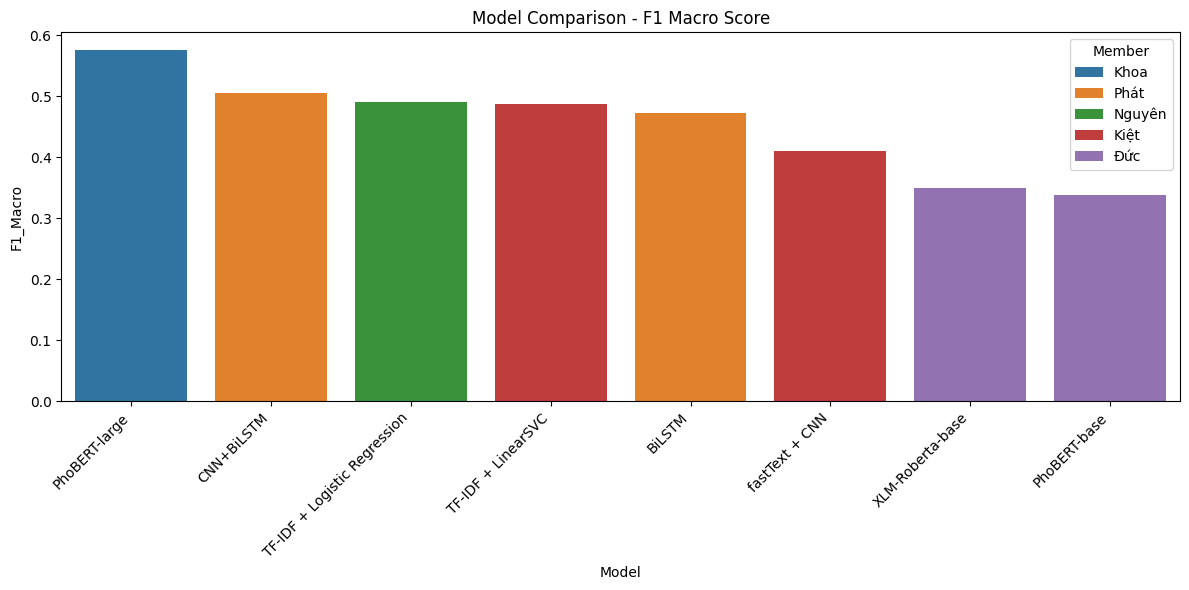

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Read filled results
#master_df = pd.read_csv('master_results_template.csv')

# Sort by F1_Micro
master_df_sorted = master_results.sort_values('F1_Macro', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=master_df_sorted, x='Model', y='F1_Macro', hue='Member')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison - F1 Macro Score')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()